<a href="https://colab.research.google.com/github/jamessutton600613-png/GC/blob/main/Copy_of_Untitled176.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit-aer qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 139.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 7.3 MB/s eta 0:00:00


In [ ]:
import os
import sys
import numpy as np # Ensure numpy is imported at the very top
import pandas as pd
import random
import pickle
from datetime import datetime
from google.colab import output
from tqdm.notebook import tqdm
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from google.colab import drive

# Mount Google Drive to save the output files
drive.mount('/content/drive', force_remount=True)

class QuantumRandomGenerator:
    def __init__(self, num_bits_precision=64):
        self.simulator = AerSimulator()
        self.num_bits = num_bits_precision

    def get_seed(self):
        qc = QuantumCircuit(self.num_bits, self.num_bits)
        qc.h(range(self.num_bits))
        qc.measure(range(self.num_bits), range(self.num_bits))
        job = self.simulator.run(transpile(qc, self.simulator), shots=1)
        return int(list(job.result().get_counts(0).keys())[0], 2)

class Environment:
    def __init__(self, rng, days_per_cycle=50):
        self.days_per_cycle, self.time, self.rng = days_per_cycle, 0, rng
        self.steps_per_year = 365 * self.days_per_cycle
        self.uv_intensity, self.temperature = self._generate_cycles(num_years=50)

    def _generate_cycles(self, num_years):
        total_steps = num_years * self.steps_per_year
        two_pi = 2 * np.pi # Calculate 2*pi separately
        daily_uv_cycle = np.sin(np.linspace(0, two_pi, self.days_per_cycle)); daily_uv_cycle[daily_uv_cycle < 0] = 0
        daily_temp_swing = -4 * np.cos(np.linspace(0, two_pi, self.days_per_cycle)) # Use the variable
        base_weather_noise = self.rng.standard_normal(total_steps)
        smoothing_window = np.ones(14 * self.days_per_cycle) / (14 * self.days_per_cycle)
        weather_pattern = np.convolve(base_weather_noise, smoothing_window, 'same') * 5.0
        full_uv, full_temp = [], []
        global_step_counter = 0
        for _ in range(num_years):
            uv_severity = self.rng.uniform(0.6, 1.4)
            seasonal_temp_base = 15 - 10 * np.cos(np.linspace(0, two_pi, self.steps_per_year))
            seasonal_amplitude_mod = (0.225 * np.sin(np.linspace(0, two_pi, self.steps_per_year)) + 0.725) * uv_severity
            daily_temp_anomaly = 0
            for i in range(self.steps_per_year):
                if i % self.days_per_cycle == 0: daily_temp_anomaly = self.rng.uniform(-1.5, 1.5)
                cloud_cover_factor = self.rng.uniform(0.7, 1.0)
                daily_uv = daily_uv_cycle[i % self.days_per_cycle] * seasonal_amplitude_mod[i] * cloud_cover_factor
                full_uv.append(daily_uv)
                solar_temp = seasonal_temp_base[i] + daily_temp_swing[i % self.days_per_cycle] + weather_pattern[global_step_counter] + daily_temp_anomaly
                full_temp.append(max(4.0, solar_temp))
                global_step_counter += 1
        return np.array(full_uv), np.array(full_temp)

    def get_current_uv(self): return self.uv_intensity[self.time % len(self.uv_intensity)]
    def get_current_temperature(self): return self.temperature[self.time % len(self.temperature)]
    def step(self): self.time += 1

class Protoribosome:
    def __init__(self, env, strategy, initial_sequence, rng, initial_mass=100.0):
        self.env, self.strategy, self.rna_sequence, self.rng = env, strategy, list(initial_sequence), rng
        self.rna_mass = initial_mass
        self.uv_protection_pool = 50.0
        self.rna_damage_level, self.location, self.status = 0.0, 'shadow_zone', 'ACTIVE'
        self.nmp_pool = {'A': 100, 'U': 100, 'G': 100, 'C': 100}
        self.ndp_pool = {'A': 50,  'U': 50,  'G': 50,  'C': 50}
        self.ntp_pool = {'A': 20,  'U': 20,  'G': 20,  'C': 20}

        if self.strategy == 'cautious': self.uv_damage_rate_per_uv = 1.0
        else: self.uv_damage_rate_per_uv = 1.4
        self.repair_rate, self.uv_protection_factor, self.damage_tolerance_threshold = 0.5, 0.01, 3.0
        self.mutation_prob = 0.004

    def calculate_protection_score(self):
        score = (len(self.rna_sequence) // 3) * 0.1
        weights = {'UGG':5.0,'UAU':3.0,'UAC':3.0,'UUU':1.5,'UUC':1.5,'UGU':1.0,'UGC':1.0,'AUG':0.75,'CAU':0.5,'CAC':0.5}
        score += sum(weights.get("".join(self.rna_sequence[i:i+3]), 0) for i in range(0, len(self.rna_sequence), 3))
        return score

    def has_stop_codon(self):
        return any("".join(self.rna_sequence[i:i+3]) in {'UAA','UAG','UGA'} for i in range(0, len(self.rna_sequence), 3))

    def _forage_and_phosphorylate(self, current_uv):
        # Foraging: Add NMPs
        for base in self.nmp_pool:
            self.nmp_pool[base] += 5 # Add 5 of each NMP per step

        # Phosphorylation: NMP to NDP
        nmp_to_ndp_conversions = 1 # Attempt to convert 1 of each NMP to NDP if available
        for base in self.nmp_pool:
            if self.nmp_pool[base] >= nmp_to_ndp_conversions:
                self.nmp_pool[base] -= nmp_to_ndp_conversions
                self.ndp_pool[base] += nmp_to_ndp_conversions
            else:
                 # Convert what's available if less than target
                self.ndp_pool[base] += self.nmp_pool[base]
                self.nmp_pool[base] = 0


        # Phosphorylation: NDP to NTP (energy-dependent)
        energy = self.uv_protection_pool * current_uv * 0.1
        ndp_to_ntp_conversions_possible = int(energy / 5) # Energy cost per conversion is 5
        ndp_to_ntp_conversions = min(ndp_to_ntp_conversions_possible, sum(self.ndp_pool.values())) # Don't convert more than available NDPs

        if ndp_to_ntp_conversions > 0:
             # Randomly select NDPs to convert to NTPs
            available_ndp_bases = [base for base, count in self.ndp_pool.items() if count > 0]
            if available_ndp_bases:
                for _ in range(ndp_to_ntp_conversions):
                    chosen_base = self.rng.choice(available_ndp_bases)
                    if self.ndp_pool[chosen_base] > 0:
                        self.ndp_pool[chosen_base] -= 1
                        self.ntp_pool[chosen_base] += 1
                    # Re-check available bases in case pool is depleted
                    available_ndp_bases = [base for base, count in self.ndp_pool.items() if count > 0]


    def _replicate_rna(self):
        # Replication requires ACTIVE status and sufficient mass for initial replication
        if self.status != 'ACTIVE' or self.rna_mass < 80:
            return None

        # Calculate required NTPs to synthesize *a second copy* of the RNA sequence
        required_ntps = {base: self.rna_sequence.count(base) for base in 'AUGC'}
        required_ntps_for_doubling = {base: count for base, count in required_ntps.items()} # Needs enough for another copy

        # Check if sufficient NTPs are available for doubling/replication
        if not all(self.ntp_pool[base] >= count for base, count in required_ntps_for_doubling.items()):
            return None # Replication fails if not enough NTPs for doubling

        # Consume the NTPs required for the second copy
        for base, count in required_ntps_for_doubling.items():
            self.ntp_pool[base] -= count

        # Conceptual mass doubling - ensures enough mass for two protoribosomes
        # We assume the consumed NTPs contribute to the mass increase needed for the second copy.
        # The total mass of the parent after consuming NTPs is effectively doubled,
        # which is then divided between parent and offspring.
        # Both parent and offspring will have mass >= 80 if initial mass was >= 80
        # and enough NTPs were available for doubling.

        offspring_mass = self.rna_mass # The offspring gets a mass equal to the parent's pre-division mass
        self.rna_mass = self.rna_mass # The parent retains its pre-division mass

        # Create the new protoribosome (offspring)
        return Protoribosome(self.env, self.strategy, "".join(self.rna_sequence), self.rng, offspring_mass)


    def step(self, current_uv):
        if self.status == 'INACTIVE': return None
        self._forage_and_phosphorylate(current_uv)

        # --- Mutation Logic ---
        if self.rng.random() < self.mutation_prob:
            if len(self.rna_sequence) > 0: # Ensure sequence is not empty
                mutation_position = self.rng.randint(0, len(self.rna_sequence))
                original_base = self.rna_sequence[mutation_position]
                # Choose a new base different from the original
                available_bases = [b for b in 'AUGC' if b != original_base]
                if available_bases: # Ensure there are other bases to mutate to
                     new_base = self.rng.choice(available_bases)
                     self.rna_sequence[mutation_position] = new_base
                     # Note: After mutation, check for stop codons happens below.
        # --- End Mutation Logic ---


        protection = self.uv_protection_pool * self.uv_protection_factor
        effective_uv = current_uv * max(0.01, 1 - protection)
        self.rna_damage_level += effective_uv * self.uv_damage_rate_per_uv
        self.rna_damage_level = max(0, self.rna_damage_level - self.repair_rate)

        if self.rna_damage_level > self.damage_tolerance_threshold: self.status = 'INACTIVE'
        has_stop = self.has_stop_codon() # Check for stop codon *after* potential mutation
        if self.strategy == 'cautious' and has_stop: self.status = 'ARRESTED'
        elif self.status == 'ARRESTED' and not has_stop: self.status = 'ACTIVE'
        elif self.strategy == 'readthrough' and has_stop: self.status = 'INACTIVE'

        if self.status == 'INACTIVE': return None
        if self.status == 'ACTIVE': self.uv_protection_pool += 0.20 * self.calculate_protection_score()

        return self._replicate_rna()

class Colony:
    def __init__(self, env, dna_template, initial_pop_size, steps_per_day, rng, shuffle_rng):
        self.env, self.dna_template, self.steps_per_day = env, dna_template, steps_per_day
        self.max_population = 10000
        self.rng, self.shuffle_rng = rng, shuffle_rng
        self.active_population = [
            Protoribosome(env, 'cautious' if i % 2 == 0 else 'readthrough', dna_template, rng)
            for i in range(initial_pop_size)
        ]
        self.inactive_population = []

    def step(self, current_step):
        # Advance the environment's time
        self.env.step() # Added call to step the environment

        current_uv = self.env.get_current_uv()
        next_generation = []
        for p in self.active_population:
            # Corrected Call: Removed the extra 'self.dna_template' argument
            offspring = p.step(current_uv)
            if p.status != 'INACTIVE':
                next_generation.append(p)
            else:
                self.inactive_population.append(p)
            if offspring:
                next_generation.append(offspring)

        self.active_population = next_generation
        if len(self.active_population) > self.max_population:
            self.shuffle_rng.shuffle(self.active_population)
            self.active_population = self.active_population[:self.max_population]

    def get_aggregated_data(self):
        data = {
            'cautious': 0, 'readthrough': 0, 'inactive': 0,
            'cautious_avg_damage': 0.0, 'readthrough_avg_damage': 0.0,
            'cautious_nmp_total': 0, 'cautious_ndp_total': 0, 'cautious_ntp_total': 0,
            'readthrough_nmp_total': 0, 'readthrough_ndp_total': 0, 'readthrough_ntp_total': 0,
            'cautious_stop_count': 0, 'readthrough_stop_count': 0
        }
        if not self.active_population:
            data['inactive'] = len(self.inactive_population)
            return data

        cautious_pop = [p for p in self.active_population if p.strategy == 'cautious']
        readthrough_pop = [p for p in self.active_population if p.strategy == 'readthrough']

        data['cautious'] = len(cautious_pop)
        data['readthrough'] = len(readthrough_pop)

        if data['cautious'] > 0:
            data['cautious_avg_damage'] = sum(p.rna_damage_level for p in cautious_pop) / data['cautious']
            data['cautious_nmp_total'] = sum(sum(p.nmp_pool.values()) for p in cautious_pop)
            data['cautious_ndp_total'] = sum(sum(p.ndp_pool.values()) for p in cautious_pop)
            data['cautious_ntp_total'] = sum(sum(p.ntp_pool.values()) for p in cautious_pop)
            data['cautious_stop_count'] = sum(1 for p in cautious_pop if p.has_stop_codon())

        if data['readthrough'] > 0:
            data['readthrough_avg_damage'] = sum(p.rna_damage_level for p in readthrough_pop) / data['readthrough']
            data['readthrough_nmp_total'] = sum(sum(p.nmp_pool.values()) for p in readthrough_pop)
            data['readthrough_ndp_total'] = sum(sum(p.ndp_pool.values()) for p in readthrough_pop)
            data['readthrough_ntp_total'] = sum(sum(p.ntp_pool.values()) for p in readthrough_pop)
            data['readthrough_stop_count'] = sum(1 for p in readthrough_pop if p.has_stop_codon())

        data['inactive'] = len(self.inactive_population)
        return data

def run_single_simulation(steps_per_day, rng, shuffle_rng, dna_template, save_dir):
    colony = Colony(Environment(rng, steps_per_day), dna_template, 5000, steps_per_day, rng, shuffle_rng)
    data_log = []
    # max_run_steps = 3 * colony.env.steps_per_year # Original full run steps
    max_run_steps = 50 # Reduced steps for debugging

    print(f"Initial active population size: {len(colony.active_population)}") # Debug print at start

    progress_bar = tqdm(desc="Simulating Replica", total=max_run_steps, leave=False)
    for step_count in range(max_run_steps):
        # print(f"Step {step_count}: Active population before step: {len(colony.active_population)}") # Debug print before step - Commented out for cleaner output
        colony.step(step_count)

        # Log data periodically, now including the time step
        if step_count % 1 == 0: # Changed logging frequency to every step
            agg_data = colony.get_aggregated_data()
            agg_data['time'] = step_count
            agg_data['uv'] = colony.env.get_current_uv()
            agg_data['temp'] = colony.env.get_current_temperature()
            data_log.append(agg_data)
            # print(f"Step: {step_count}, data_log length: {len(data_log)}") # Debug print inside logging - Commented out for cleaner output

        # Update progress bar periodically
        if step_count % 50 == 0:
            c = agg_data.get('cautious', 0)
            r = agg_data.get('readthrough', 0)
            progress_bar.set_postfix_str(f"Cautious:{c}, Reckless:{r}")

        progress_bar.update(1)
        # print(f"Step {step_count}: Active population after step: {len(colony.active_population)}") # Debug print after step - Commented out for cleaner output
        if len(colony.active_population) == 0:
            print("--- Population extinct. ---")
            break

    progress_bar.close()

    print(f"Simulation finished. Final data_log length: {len(data_log)}") # Debug print before saving

    # Create and save the data file in the format the plotter expects
    log_df = pd.DataFrame(data_log)
    output_path = os.path.join(save_dir, 'simulation_log.pkl')
    with open(output_path, 'wb') as f:
        pickle.dump({'log': log_df.to_dict('records')}, f)

    # Define details_df here before returning
    details_df = log_df

    final_agg = colony.get_aggregated_data()
    final_c, final_r = final_agg.get('cautious', 0), final_agg.get('readthrough', 0)
    winner = "Cautious" if final_r == 0 and final_c > 0 else "Reckless" if final_c == 0 and final_r > 0 else "Tie/Extinction"
    summary = {'Winner':winner,'Duration':step_count,'Final Cautious':final_c,'Final Reckless':final_r}

    return summary, details_df

def main_orchestrator(num_replicas, steps_per_day):
    DNA_TEMPLATE = "AUGUGUUACUGG"
    all_summaries = []

    # Define a base directory for experiments in Google Drive
    base_save_dir = '/content/drive/My Drive/Colab Notebooks/Sim_Experiments'
    experiment_dir = os.path.join(base_save_dir, f"Experiment_{datetime.now().strftime('%Y-%m-%d_%H-%M')}")
    os.makedirs(experiment_dir, exist_ok=True)

    for i in range(1, num_replicas + 1):
        print(f"\n--- Processing Replica {i}/{num_replicas} ---")
        q_rng = QuantumRandomGenerator(29)
        quantum_seed = q_rng.get_seed()
        sim_rng = np.random.default_rng(seed=quantum_seed)
        shuffle_rng = random.Random(quantum_seed)

        replica_dir = os.path.join(experiment_dir, f"Replica_{i}")
        os.makedirs(replica_dir, exist_ok=True)

        # Corrected Call: Removed extra argument and pass the save directory
        summary, details_df = run_single_simulation(steps_per_day, sim_rng, shuffle_rng, DNA_TEMPLATE, replica_dir)
        summary['Replica'] = i
        all_summaries.append(summary)

        print(f"Data for Replica {i} saved in: {replica_dir}")

    print("\n\n" + "="*80 + "\n" + " EXPERIMENT SUMMARY ".center(80, "="))
    if all_summaries:
        summary_df = pd.DataFrame(all_summaries).set_index('Replica')
        print(summary_df.to_string())
    print("="*80)

if __name__ == "__main__":
    # Run 2 replicas with 10 steps per day for demonstration
    main_orchestrator(num_replicas=2, steps_per_day=10)

Mounted at /content/drive

--- Processing Replica 1/2 ---
Initial active population size: 5000


Simulating Replica:   0%|          | 0/50 [00:00<?, ?it/s]

AttributeError: 'numpy.random._generator.Generator' object has no attribute 'randint'

Found latest experiment directory: Experiment_2025-07-05_16-25
Using data from first replica directory: Replica_1
Loading data from simulation_log.pkl...
Type of loaded data: <class 'dict'>
Successfully loaded log with 50 entries.


/tmp/ipython-input-37-524950560.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


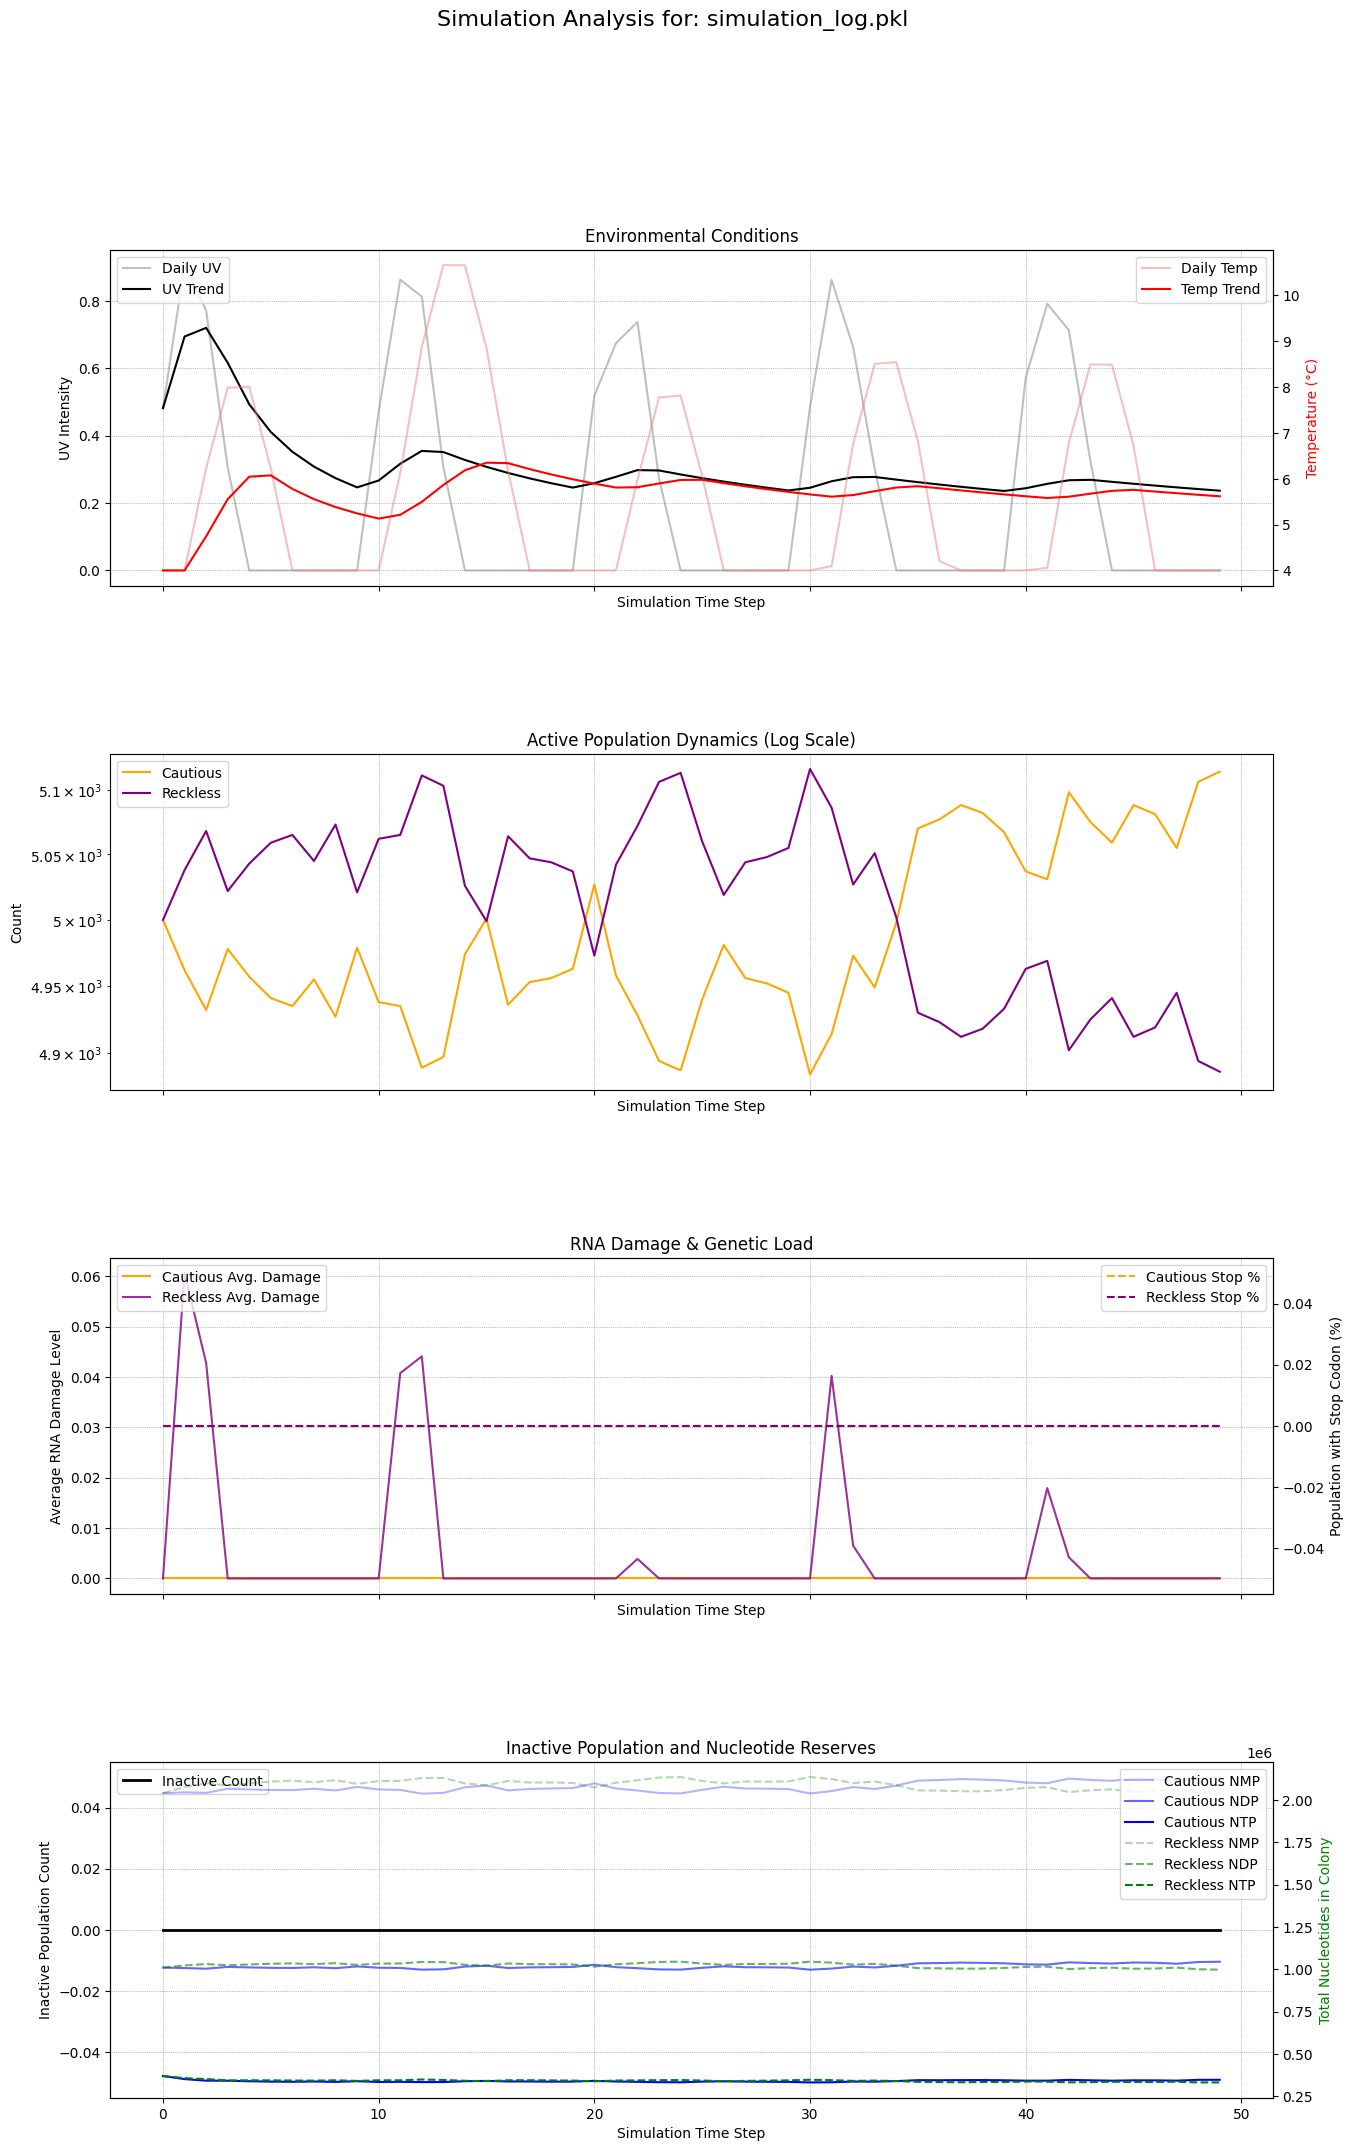

In [ ]:
%matplotlib inline
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# ===================================================================
# === 1. SET THE BASE PATH TO YOUR SIMULATION EXPERIMENTS FOLDER ===
# ===================================================================
# This path should point to the folder where the Simulation Runner creates
# the timestamped experiment subfolders (e.g., 'Sim_Experiments').
BASE_EXPERIMENTS_PATH = '/content/drive/My Drive/Colab Notebooks/Sim_Experiments'
# ===================================================================

def find_latest_simulation_log(base_path):
    """
    Finds the simulation_log.pkl file in the first replica folder
    of the latest experiment directory within the base path.
    """
    if not os.path.exists(base_path):
        print(f"Error: Base experiments path not found at {base_path}")
        return None

    # Find all experiment directories
    # Assuming experiment directories are named like "Experiment_YYYY-MM-DD_HH-MM"
    experiment_dirs = sorted(
        [d for d in glob.glob(os.path.join(base_path, 'Experiment_*')) if os.path.isdir(d)],
        key=os.path.getmtime,
        reverse=True
    )

    if not experiment_dirs:
        print(f"Error: No experiment directories found in {base_path}")
        return None

    latest_experiment_dir = experiment_dirs[0]
    print(f"Found latest experiment directory: {os.path.basename(latest_experiment_dir)}")

    # Find the first replica directory within the latest experiment
    replica_dirs = sorted(
        [d for d in glob.glob(os.path.join(latest_experiment_dir, 'Replica_*')) if os.path.isdir(d)],
        key=os.path.getmtime
    )

    if not replica_dirs:
        print(f"Error: No replica directories found in {latest_experiment_dir}")
        return None

    first_replica_dir = replica_dirs[0]
    print(f"Using data from first replica directory: {os.path.basename(first_replica_dir)}")

    # Construct the full path to the simulation_log.pkl file
    log_file_path = os.path.join(first_replica_dir, 'simulation_log.pkl')

    if not os.path.exists(log_file_path):
        print(f"Error: simulation_log.pkl not found in {first_replica_dir}")
        return None

    return log_file_path


def plot_simulation_details(results_df, file_name=""):
    """
    Generates and displays the four plots you specified.
    """
    if results_df.empty:
        print("The DataFrame is empty. No data to plot.")
        return

    # Calculate Stop Codon Percentages safely, avoiding division by zero
    results_df['cautious_stop_pct'] = (results_df['cautious_stop_count'] * 100 / results_df['cautious']).fillna(0)
    results_df['reckless_stop_pct'] = (results_df['readthrough_stop_count'] * 100 / results_df['readthrough']).fillna(0)

    fig, axs = plt.subplots(4, 1, figsize=(15, 24), sharex=True, gridspec_kw={'hspace': 0.5})
    fig.suptitle(f'Simulation Analysis for: {file_name}', fontsize=16)
    colors = {'cautious': 'orange', 'readthrough': 'purple'}
    rolling_window = 100

    # Plot 1: Environmental Conditions
    ax = axs[0]
    ax.set_title('Environmental Conditions')
    ax.plot(results_df['time'], results_df['uv'], color='gray', alpha=0.5, label='Daily UV')
    ax.plot(results_df['time'], results_df['uv'].rolling(window=rolling_window, min_periods=1).mean(), color='black', label='UV Trend')
    ax.set_ylabel('UV Intensity'); ax.legend(loc='upper left')
    ax_t = ax.twinx()
    ax_t.plot(results_df['time'], results_df['temp'], color='lightcoral', alpha=0.5, label='Daily Temp')
    ax_t.plot(results_df['time'], results_df['temp'].rolling(window=rolling_window, min_periods=1).mean(), color='red', label='Temp Trend')
    ax_t.set_ylabel('Temperature (°C)', color='r'); ax_t.legend(loc='upper right')

    # Plot 2: Population Dynamics (Log Scale)
    ax = axs[1]
    ax.set_title('Active Population Dynamics (Log Scale)')
    ax.plot(results_df['time'], results_df['cautious'], label='Cautious', color=colors['cautious'])
    ax.plot(results_df['time'], results_df['readthrough'], label='Reckless', color=colors['readthrough'])
    ax.set_yscale('log'); ax.set_ylabel('Count'); ax.legend()

    # Plot 3: RNA Damage & Stop Codon Percentage
    ax = axs[2]
    ax.set_title('RNA Damage & Genetic Load')
    ax.plot(results_df['time'], results_df['cautious_avg_damage'], label='Cautious Avg. Damage', color=colors['cautious'])
    ax.plot(results_df['time'], results_df['readthrough_avg_damage'], label='Reckless Avg. Damage', color=colors['readthrough'], alpha=0.8)
    ax.set_ylabel('Average RNA Damage Level'); ax.legend(loc='upper left')
    ax_t = ax.twinx()
    ax_t.plot(results_df['time'], results_df['cautious_stop_pct'], label='Cautious Stop %', color=colors['cautious'], linestyle='--')
    ax_t.plot(results_df['time'], results_df['reckless_stop_pct'], label='Reckless Stop %', color=colors['readthrough'], linestyle='--')
    ax_t.set_ylabel('Population with Stop Codon (%)'); ax_t.legend(loc='upper right')

    # Plot 4: Inactives and Nucleotide Pools
    ax = axs[3]
    ax.set_title('Inactive Population and Nucleotide Reserves')
    ax.plot(results_df['time'], results_df['inactive'], label='Inactive Count', color='black', lw=2)
    ax.set_ylabel('Inactive Population Count'); ax.legend(loc='upper left')
    ax_t = ax.twinx()
    ax_t.plot(results_df['time'], results_df['cautious_nmp_total'], color='blue', alpha=0.3, label='Cautious NMP')
    ax_t.plot(results_df['time'], results_df['cautious_ndp_total'], color='blue', alpha=0.6, label='Cautious NDP')
    ax_t.plot(results_df['time'], results_df['cautious_ntp_total'], color='blue', alpha=1.0, label='Cautious NTP')
    ax_t.plot(results_df['time'], results_df['readthrough_nmp_total'], color='green', alpha=0.3, linestyle='--', label='Reckless NMP')
    ax_t.plot(results_df['time'], results_df['readthrough_ndp_total'], color='green', alpha=0.6, linestyle='--', label='Reckless NDP')
    ax_t.plot(results_df['time'], results_df['readthrough_ntp_total'], color='green', alpha=1.0, linestyle='--', label='Reckless NTP')
    ax_t.set_ylabel('Total Nucleotides in Colony', color='g'); ax_t.legend(loc='upper right')

    for ax_item in axs:
        ax_item.grid(True, linestyle=':', linewidth='0.5', color='gray')
        ax_item.set_xlabel('Simulation Time Step')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    plt.close(fig)

# --- Main Execution Logic for this Cell ---
DATA_FILE_PATH = find_latest_simulation_log(BASE_EXPERIMENTS_PATH)

if DATA_FILE_PATH and os.path.exists(DATA_FILE_PATH):
    try:
        print(f"Loading data from {os.path.basename(DATA_FILE_PATH)}...")
        with open(DATA_FILE_PATH, 'rb') as f:
            saved_data = pickle.load(f)

        # Debugging: Print the type and content of saved_data
        print(f"Type of loaded data: {type(saved_data)}")
        # print(f"Content of loaded data (first 100 chars): {str(saved_data)[:100]}...") # Optional: print start of content

        # The primary save file from the runner is the full state dictionary
        if isinstance(saved_data, dict) and 'log' in saved_data:
            results_df = pd.DataFrame(saved_data['log'])
            print(f"Successfully loaded log with {len(results_df)} entries.")
            plot_simulation_details(results_df, file_name=os.path.basename(DATA_FILE_PATH))
        else:
            print("Error: The pickle file does not contain the expected 'log' data dictionary.")
            print(f"Loaded data type: {type(saved_data)}")


    except Exception as e:
        print(f"\n--- ERROR: Could not load or plot the data file. ---")
        print(f"The error was: {e}")
else:
    print(f"--- ERROR: Could not find or access the latest simulation log file. ---")
    print(f"Please ensure the BASE_EXPERIMENTS_PATH is correct and that simulation runs have completed successfully.")

In [ ]:
# Display the first few rows of the DataFrame
print("First 5 rows of the results_df:")
display(results_df.head())

# Display the last few rows of the DataFrame
print("\nLast 5 rows of the results_df:")
display(results_df.tail())

First 5 rows of the results_df:


,cautious,readthrough,inactive,cautious_avg_damage,readthrough_avg_damage,cautious_nmp_total,cautious_ndp_total,cautious_ntp_total,readthrough_nmp_total,readthrough_ndp_total,readthrough_ntp_total,cautious_stop_count,readthrough_stop_count,time,uv,temp,cautious_stop_pct,reckless_stop_pct
0,5000,5000,0,0.0,0.0,400090000,200010000,9970000,400090000,200010000,9970000,4,2,0,0.6823254203414715,15.658226733552418,0.080000,0.04
1,4842,5158,4,0.0,0.0,388307700,193785300,9630408,413647964,206431996,10257128,1,0,10,0.6823254203414715,15.658226733552418,0.020653,0.00



Last 5 rows of the results_df:


,cautious,readthrough,inactive,cautious_avg_damage,readthrough_avg_damage,cautious_nmp_total,cautious_ndp_total,cautious_ntp_total,readthrough_nmp_total,readthrough_ndp_total,readthrough_ntp_total,cautious_stop_count,readthrough_stop_count,time,uv,temp,cautious_stop_pct,reckless_stop_pct
0,5000,5000,0,0.0,0.0,400090000,200010000,9970000,400090000,200010000,9970000,4,2,0,0.6823254203414715,15.658226733552418,0.080000,0.04
1,4842,5158,4,0.0,0.0,388307700,193785300,9630408,413647964,206431996,10257128,1,0,10,0.6823254203414715,15.658226733552418,0.020653,0.00


In [ ]:
# Display the first few rows of the DataFrame focusing on relevant columns
print("First 5 rows of the results_df (UV, Temp, Stop Pct):")
display(results_df[['time', 'uv', 'temp', 'cautious_stop_pct', 'reckless_stop_pct']].head())

# Display the last few rows of the DataFrame focusing on relevant columns
print("\nLast 5 rows of the results_df (UV, Temp, Stop Pct):")
display(results_df[['time', 'uv', 'temp', 'cautious_stop_pct', 'reckless_stop_pct']].tail())

First 5 rows of the results_df (UV, Temp, Stop Pct):


,time,uv,temp,cautious_stop_pct,reckless_stop_pct
0,0,0.0,4.0,0.0,0.0
1,1,0.0,4.0,0.0,0.0
2,2,0.0,4.0,0.0,0.0
3,3,0.0,4.0,0.0,0.0
4,4,0.0,4.0,0.0,0.0



Last 5 rows of the results_df (UV, Temp, Stop Pct):


,time,uv,temp,cautious_stop_pct,reckless_stop_pct
45,45,0.0,4.0,0.0,0.0
46,46,0.0,4.0,0.0,0.0
47,47,0.0,4.0,0.0,0.0
48,48,0.0,4.0,0.0,0.0
49,49,0.0,4.0,0.0,0.0
